This notebook produces the figures depicting the data in my thesis: morpoholgies and experimental voltage recordings.

In [1]:
import sys
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"


%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax.numpy as jnp
import jaxley as jx


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


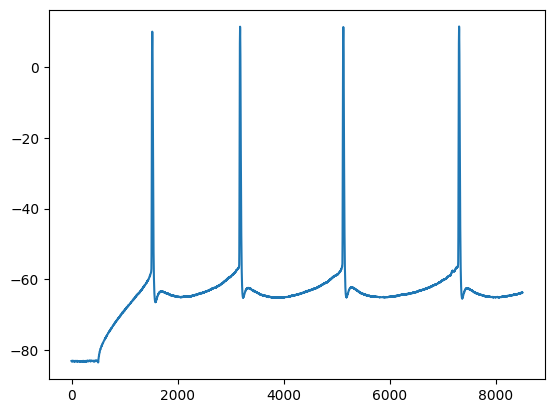

In [2]:
t_max = 250
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"

# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data
)

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

plt.plot(v_data[0])

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in

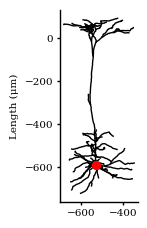

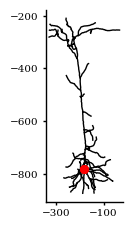

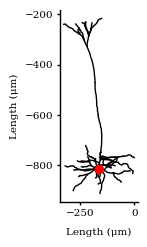

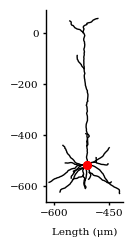

In [3]:
base_path = "/Users/moldor/Documents/Thesis/universal_diff_eq/voltage_fitting"

cell1 = jx.read_swc(f"{base_path}/cell_types/specimen_{setup}/reconstruction.swc", ncomp=4, assign_groups=True)
cell1.rotate(195)
cell2 = jx.read_swc(f"{base_path}/cell_types/specimen_485574832/reconstruction.swc", ncomp=4)
cell2.rotate(155)
cell3 = jx.read_swc(f"{base_path}/cell_types/specimen_480353286/reconstruction.swc", ncomp=4)
cell3.rotate(170)
cell4 = jx.read_swc(f"{base_path}/cell_types/specimen_473601979/reconstruction.swc", ncomp=4)
cell4.rotate(195)

cell1.compute_xyz()  # Only needed for visualization.
cell2.compute_xyz()
cell3.compute_xyz()
cell4.compute_xyz()

import matplotlib as mpl
import matplotlib.pyplot as plt

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, ax = plt.subplots(1, 1, figsize=(1, 2.5))
    # for spine in ax.spines.values():
    #     spine.set_visible(False)
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_ylabel("Length (μm)")
    _ = cell1.vis(ax=ax, color="k")
    _ = cell1.soma.branch(0).comp(0).vis(ax=ax, color="r", type='scatter', s = 30, zorder = 10)
    fig.savefig("../svg/morph_488683425.svg")

    fig, ax = plt.subplots(1, 1, figsize=(1, 2.5))
    # for spine in ax.spines.values():
    #     spine.set_visible(False)
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_xticks([-300, -100])
    _ = cell2.vis(ax=ax, color="k")
    _ = cell2.soma.branch(0).comp(0).vis(ax=ax, color="r", type='scatter', s = 30, zorder = 10)
    fig.savefig("../svg/morph_485574832.svg")

    fig, ax = plt.subplots(1, 1, figsize=(1, 2.5))
    # for spine in ax.spines.values():
    #     spine.set_visible(False)
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_xlabel("Length (μm)", labelpad=7)
    ax.set_ylabel("Length (μm)")
    _ = cell3.vis(ax=ax, color="k")
    _ = cell3.soma.branch(0).comp(0).vis(ax=ax, color="r", type='scatter', s = 30, zorder = 10)
    fig.savefig("../svg/morph_480353286.svg")

    fig, ax = plt.subplots(1, 1, figsize=(1, 2.5))
    # for spine in ax.spines.values():
    #     spine.set_visible(False)
    ax.set_xticks([-600, -450])
    # ax.set_yticks([])
    ax.set_xlabel("Length (μm)", labelpad=7)
    _ = cell4.vis(ax=ax, color="k")
    _ = cell4.soma.branch(0).comp(0).vis(ax=ax, color="r", type='scatter', s = 30, zorder = 10)
    fig.savefig("../svg/morph_473601979.svg")


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
dt_difference 5.0
Amplitude stimulus: 0.33000001311302185
dt_difference 5.0
Amplitude stimulus: 0.26999998092651367
dt_difference 5.0
Amplitude stimulus: 0.17000000178813934


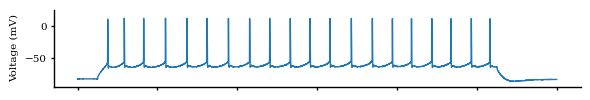

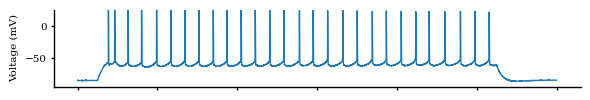

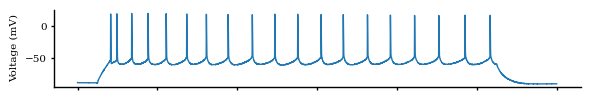

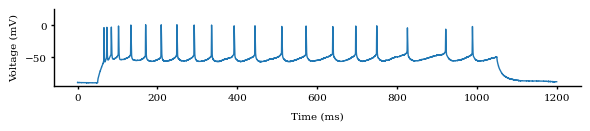

In [4]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    time_vec, data1, i_amp = get_experimental_data(setup, t_max = 1500)
    fig, ax = plt.subplots(1,1,figsize=(6.8,1))
    ax.plot(time_vec, data1)
    ax.set_ylim([-95, 25])
    ax.set_xticklabels([])
    ax.set_ylabel("Voltage (mV)")
    fig.savefig("../svg/rec_488683425.svg")

    time_vec, data1, i_amp = get_experimental_data('485574832', t_max = 1500)
    fig, ax = plt.subplots(1,1,figsize=(6.8,1))
    ax.plot(time_vec, data1)
    ax.set_ylim([-95, 25])
    ax.set_xticklabels([])
    ax.set_ylabel("Voltage (mV)")
    fig.savefig("../svg/rec_485574832.svg")

    time_vec, data1, i_amp = get_experimental_data('480353286', t_max = 1500)
    fig, ax = plt.subplots(1,1,figsize=(6.8,1))
    ax.plot(time_vec, data1)
    ax.set_ylim([-95, 25])
    ax.set_xticklabels([])
    ax.set_ylabel("Voltage (mV)")
    fig.savefig("../svg/rec_480353286.svg")

    time_vec, data1, i_amp = get_experimental_data('473601979', t_max = 1500)
    fig, ax = plt.subplots(1,1,figsize=(6.8,1))
    ax.plot(time_vec, data1)
    ax.set_ylim([-95, 25])
    ax.set_xlabel("Time (ms)", labelpad=7)
    ax.set_ylabel("Voltage (mV)")
    fig.savefig("../svg/rec_473601979.svg")

In [5]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.6cm", "12.5cm",
           
    Panel(
          SVG("../svg/morph_488683425.svg").scale(svg_scale),
          Text("A", 10, 2.0, **kwargs_text),
    ).move(10, 20),
    
    Panel(
          SVG("../svg/morph_485574832.svg").scale(svg_scale),
          Text("B", 10, 2.0, **kwargs_text),
    ).move(130, 20),

    Panel(
          SVG("../svg/morph_480353286.svg").scale(svg_scale),
          Text("C", 10, -2.0, **kwargs_text),
    ).move(10, 245),

    Panel(
          SVG("../svg/morph_473601979.svg").scale(svg_scale),
          Text("D", 10, -2.0, **kwargs_text),
    ).move(130, 245),

    Panel(
          SVG("../svg/rec_488683425.svg").scale(svg_scale),
          Text("a", 0, 2.0, **kwargs_text),
    ).move(250, 20),
    
    Panel(
          SVG("../svg/rec_485574832.svg").scale(svg_scale),
          Text("b", 0, 2.0, **kwargs_text),
    ).move(250, 130),

    Panel(
          SVG("../svg/rec_480353286.svg").scale(svg_scale),
          Text("c", 0, 2.0, **kwargs_text),
    ).move(250, 240),

    Panel(
          SVG("../svg/rec_473601979.svg").scale(svg_scale),
          Text("d", 0, 2.0, **kwargs_text),
    ).move(250, 350),


)

#!mkdir -p fig
f.save("../fig/data.svg")
svg("../fig/data.svg")

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in

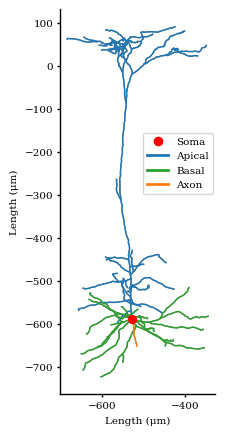

In [6]:
base_path = "/Users/moldor/Documents/Thesis/universal_diff_eq/voltage_fitting"

cell1 = jx.read_swc(f"{base_path}/cell_types/specimen_{setup}/reconstruction.swc", ncomp=4, assign_groups=True)
cell1.rotate(195)
cell2 = jx.read_swc(f"{base_path}/cell_types/specimen_485574832/reconstruction.swc", ncomp=4)
cell2.rotate(155)
cell3 = jx.read_swc(f"{base_path}/cell_types/specimen_480353286/reconstruction.swc", ncomp=4)
cell3.rotate(170)
cell4 = jx.read_swc(f"{base_path}/cell_types/specimen_473601979/reconstruction.swc", ncomp=4)
cell4.rotate(195)

cell1.compute_xyz()  # Only needed for visualization.
cell2.compute_xyz()
cell3.compute_xyz()
cell4.compute_xyz()

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, ax = plt.subplots(1, 1, figsize=(2, 5))
    _ = cell1.vis(ax=ax, color="gray")  # overall outline
    _ = cell1.soma.branch(0).comp(0).vis(ax=ax, color="red", type='scatter', s=30, zorder=10)  # soma
    _ = cell1.apical.vis(ax=ax, color="#1f77b4")   # apical: blue
    _ = cell1.basal.vis(ax=ax, color="#2ca02c")    # basal: green
    _ = cell1.axon.vis(ax=ax, color="#ff7f0e")     # axon: orange

    ax.set_xlabel("Length (μm)")
    ax.set_ylabel("Length (μm)")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor="red", markersize=8, label="Soma"),
        Line2D([0], [0], color="#1f77b4", lw=2, label="Apical"),
        Line2D([0], [0], color="#2ca02c", lw=2, label="Basal"),
        Line2D([0], [0], color="#ff7f0e", lw=2, label="Axon"),
    ]

    # Add the legend to the plot
    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(0.5, 0.6),  # Slightly to the right of the axes
        ncol=1,
        frameon=True
    )

    fig.savefig("../svg/multicomp_morph_488683425.svg")

In [7]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("5.1cm", "10.3cm",
           
    Panel(
          SVG("../svg/multicomp_morph_488683425.svg").scale(svg_scale),
    ).move(0, 0),


)

#!mkdir -p fig
f.save("../fig/multi_morph.svg")
svg("../fig/multi_morph.svg")